In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
#step 3: slect features
X = df[['Annual Income (k$)','Spending Score (1-100)']]

In [10]:
from sklearn.preprocessing import StandardScaler
Scaler=StandardScaler()
X_scaled=Scaler.fit_transform(X)

# KMeans clustering

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

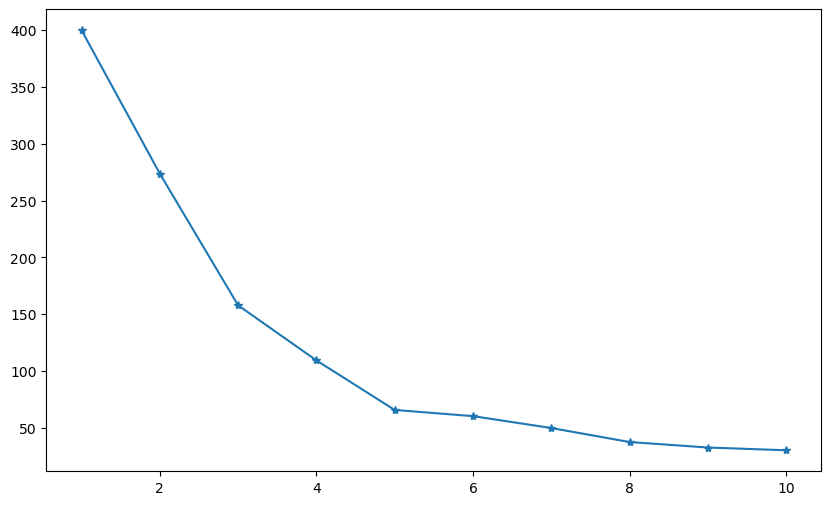

In [14]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
    kmeans_model=KMeans(n_clusters=i,random_state=42)
    kmeans_model.fit(X_scaled)
    wcss.append(kmeans_model.inertia_)
plt.figure(figsize=(10,6))
plt.plot(range(1,11),wcss,marker='*')
plt.show()

In [18]:
KMeans_model=KMeans(n_clusters=5,random_state=42)
df['KMeans_cluster']=KMeans_model.fit_predict(X_scaled)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [21]:
df['KMeans_cluster']=df['KMeans_cluster']+1

Note: In USL Fit and Prediction is always done at a time due data is unlabeled (model.fit_predict())

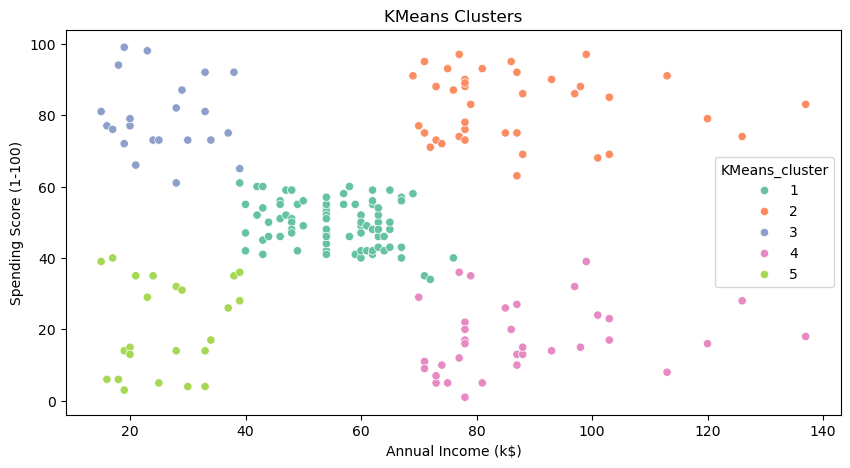

In [30]:
import seaborn as sns
plt.figure(figsize=(10,5))
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['KMeans_cluster'],
    palette='Set2'
)
plt.title('KMeans Clusters')
plt.show()

In [31]:
df.groupby('KMeans_cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
KMeans_cluster,,,,
1,86.320988,42.716049,55.296296,49.518519
2,162.000000,32.692308,86.538462,82.128205
3,23.090909,25.272727,25.727273,79.363636
4,164.371429,41.114286,88.200000,17.114286
5,23.000000,45.217391,26.304348,20.913043


# Heirarchical Clustering

# 1) Agglomerative clustering

In [35]:
from sklearn.cluster import AgglomerativeClustering
hc=AgglomerativeClustering(n_clusters=5)
df['hc_cluster']=hc.fit_predict(X_scaled)
df['hc_cluster']=df['hc_cluster']+1

<function matplotlib.pyplot.show(close=None, block=None)>

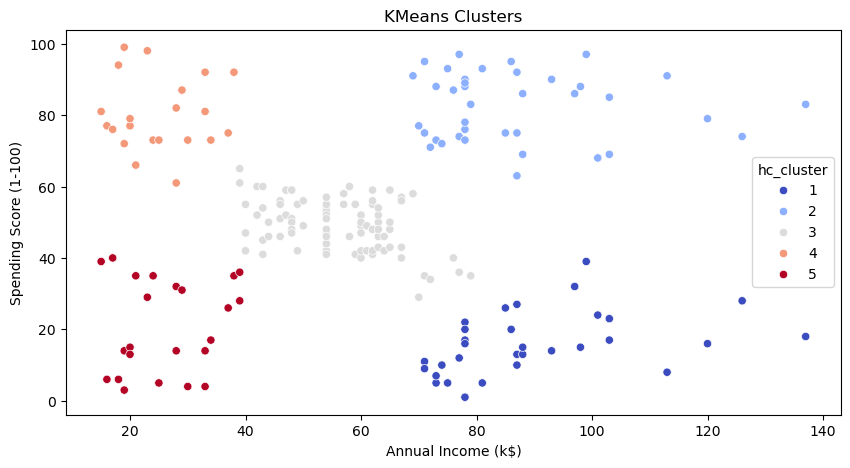

In [36]:
# plot the visual of cluster
import seaborn as sns 
plt.figure(figsize=(10,5))
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['hc_cluster'],
    palette='coolwarm'
)
plt.title('KMeans Clusters')
plt.show

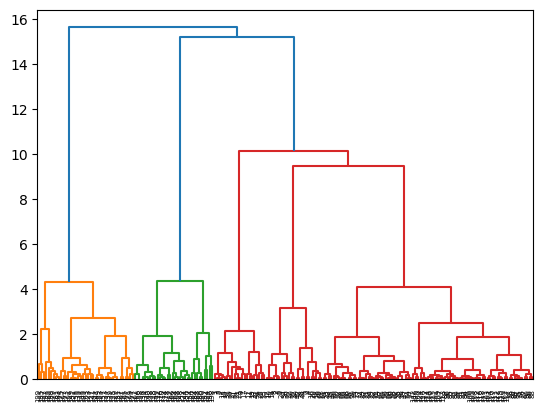

<Figure size 1000x500 with 0 Axes>

In [38]:
from scipy.cluster.hierarchy import dendrogram, linkage
linked=linkage(X_scaled, method='ward')
dendrogram(linked)
plt.figure(figsize=(10,5))
plt.show()

# DBSCAN- Density Based single cluster analysis

<function matplotlib.pyplot.show(close=None, block=None)>

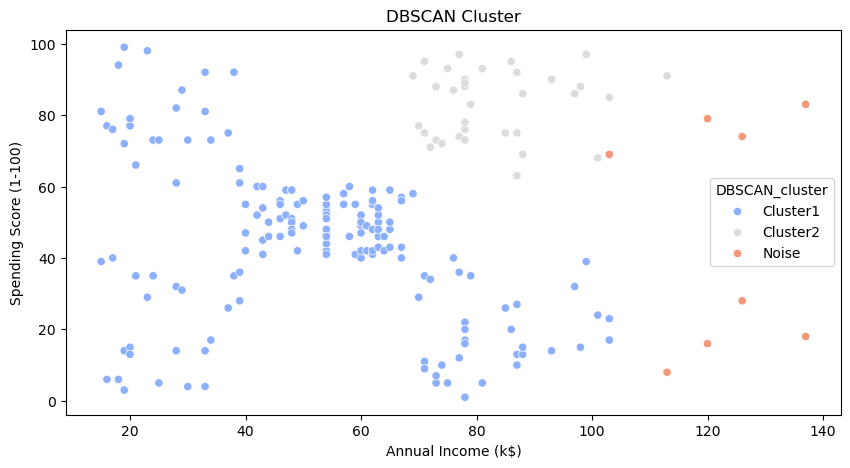

In [43]:
from sklearn.cluster import DBSCAN 
db=DBSCAN(eps=0.5,min_samples=5)
df["DBSCAN_cluster"]=db.fit_predict(X_scaled)
df["DBSCAN_cluster"]=df["DBSCAN_cluster"].apply(
    lambda x:"Noise" if x==-1 else f"Cluster{x+1}"
)
plt.figure(figsize=(10,5))
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['DBSCAN_cluster'],
    palette='coolwarm'
)
plt.title('DBSCAN Cluster')
plt.show